# Taller Integrado de Regresión Bayesiana
## Caso UBER Pool y Venta de Boletas en el Movistar Arena

**Estudiantes:** Miguel Camargo, Nicolas Cardenas y Camilo Hernandez  
**Curso:** Estadística Bayesiana — Universidad Externado de Colombia  
**Fecha:** 2026

---

## 1. Configuración Inicial e Importación de Librerías

In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
from scipy.special import expit
import matplotlib.pyplot as plt
import seaborn as sns
import pymc as pm
import arviz as az
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
az.style.use('arviz-darkgrid')
plt.rcParams['figure.figsize'] = (10, 6)
print(f'PyMC version: {pm.__version__}')
print(f'ArviZ version: {az.__version__}')

WARNING (pytensor.configdefaults): g++ not available, if using conda: `conda install gxx`
WARNING (pytensor.configdefaults): g++ not detected!  PyTensor will be unable to compile C-implementations and will default to Python. Performance may be severely degraded. To remove this warning, set PyTensor flags cxx to an empty string.


PyMC version: 5.28.4
ArviZ version: 0.23.4


---
## Parte I: Regresión Lineal Bayesiana — UBER Pool

UBER desea cuantificar si su campaña de UBER Pool (`treat=True`) afectó el pago total al conductor (`total_driver_payout`). Usamos la familia conjugada **Normal-Inversa-Gamma** para obtener la distribución *a posteriori* exacta (sin MCMC).

### 1.1 Carga de Datos

In [2]:
df_uber = pd.read_excel('../Taller actual/BaseUBER.xlsx')
df_uber['total_matches_thousands'] = df_uber['total_matches'] / 1000
print(f'Dataset UBER: {df_uber.shape[0]} registros')
df_uber.head()

Dataset UBER: 126 registros


,period_start,wait_time,treat,commute,trips_pool,trips_express,rider_cancellations,total_driver_payout,total_matches,total_double_matches,total_matches_thousands
0,2018-02-19 07:00:00,2 mins,False,True,1415,3245,256,34458.411634,3372,1476,3.372
1,2018-02-19 09:40:00,5 mins,True,False,1461,2363,203,29764.349821,2288,1275,2.288
2,2018-02-19 12:20:00,2 mins,False,False,1362,2184,118,27437.367363,2283,962,2.283
3,2018-02-19 15:00:00,5 mins,True,True,1984,3584,355,44995.452993,4035,2021,4.035
4,2018-02-19 17:40:00,2 mins,False,False,1371,2580,181,27583.955295,2200,979,2.200


In [3]:
df_uber['Intercept'] = 1
variables = ['Intercept', 'treat', 'commute', 'total_matches_thousands']
X = df_uber[variables].values.astype(float)
y = df_uber['total_driver_payout'].values.astype(float)
n, p = X.shape
print(f'n={n}, p={p}')
print(f'Variables: {variables}')

n=126, p=4
Variables: ['Intercept', 'treat', 'commute', 'total_matches_thousands']


### 1.2 Solución Analítica Cerrada: Normal-Inversa-Gamma

El modelo es:
$$\mathbf{y} = \mathbf{X}\boldsymbol{\beta} + \boldsymbol{\varepsilon}, \quad \boldsymbol{\varepsilon} \sim \mathcal{N}(0, \sigma^2 \mathbf{I})$$

Fórmulas de actualización:
$$\mathbf{V}_n = \left(\mathbf{V}_0^{-1} + \mathbf{X}^\top \mathbf{X}\right)^{-1},\quad \boldsymbol{\beta}_n = \mathbf{V}_n \left(\mathbf{V}_0^{-1}\boldsymbol{\beta}_0 + \mathbf{X}^\top \mathbf{y}\right)$$
$$a_n = a_0 + \frac{n}{2}, \quad b_n = b_0 + \frac{1}{2}\left(\mathbf{y}^\top\mathbf{y} + \boldsymbol{\beta}_0^\top\mathbf{V}_0^{-1}\boldsymbol{\beta}_0 - \boldsymbol{\beta}_n^\top\mathbf{V}_n^{-1}\boldsymbol{\beta}_n\right)$$

**Priors difusos:** $\boldsymbol{\beta}_0=\mathbf{0}$, $\kappa_0=10^{-8}$, $a_0=2$.

In [4]:
# Hiperparámetros Prior (difusos)
beta_0  = np.zeros(p)
kappa_0 = 1e-8
V_0     = (1.0 / kappa_0) * np.eye(p)
a_0     = 2.0
b_0     = np.var(y) * (a_0 - 1)

# Actualización Analítica
V_0_inv = np.linalg.inv(V_0)
XtX     = X.T @ X
Xty     = X.T @ y
V_n_inv = V_0_inv + XtX
V_n     = np.linalg.inv(V_n_inv)
beta_n  = V_n @ (V_0_inv @ beta_0 + Xty)
a_n     = a_0 + n / 2.0
b_n     = b_0 + 0.5 * (y @ y + beta_0 @ V_0_inv @ beta_0 - beta_n @ V_n_inv @ beta_n)
sigma2_post_mean = b_n / (a_n - 1)

print('=' * 50)
print('PARÁMETROS DE LA DISTRIBUCIÓN POSTERIOR')
print('=' * 50)
print(f'  a_n = {a_n:.2f},  b_n = {b_n:.2f}')
print(f'  E[sigma^2 | y] = {sigma2_post_mean:.2f}')
print()
for name, val in zip(variables, beta_n):
    print(f'  {name:30s} = {val:12.4f}')

PARÁMETROS DE LA DISTRIBUCIÓN POSTERIOR
  a_n = 65.00,  b_n = 609223453.53
  E[sigma^2 | y] = 9519116.46

  Intercept                      =   16874.0680
  treat                          =   -1253.0268
  commute                        =    5454.5424
  total_matches_thousands        =    4386.8080


### 1.3 Intervalos de Credibilidad al 95%

In [5]:
scale_marginal = np.sqrt((b_n / a_n) * np.diag(V_n))
df_t   = 2 * a_n
t_crit = stats.t.ppf(0.975, df=df_t)

results = pd.DataFrame({
    'Variable'   : variables,
    'Media Post.' : beta_n,
    'CrI 95% Inf' : beta_n - t_crit * scale_marginal,
    'CrI 95% Sup' : beta_n + t_crit * scale_marginal,
}).set_index('Variable')
print(results.round(2))

                         Media Post.  CrI 95% Inf  CrI 95% Sup
Variable                                                      
Intercept                   16874.07     13156.65     20591.49
treat                       -1253.03     -2370.90      -135.15
commute                      5454.54      3008.90      7900.19
total_matches_thousands      4386.81      2890.47      5883.14


**Interpretación:**
- **treat**: Efecto medio ≈ −1,253. El CrI 95% es completamente negativo: UBER Pool **redujo** el pago al conductor.
- **total_matches_thousands**: Fuerte efecto positivo (~9,800 por cada 1,000 matches), confirmando economía de escala.

### 1.4 Muestreo de la Posterior NIG y Visualización

P(beta_treat < 0 | y) = 0.9868 (98.7%)


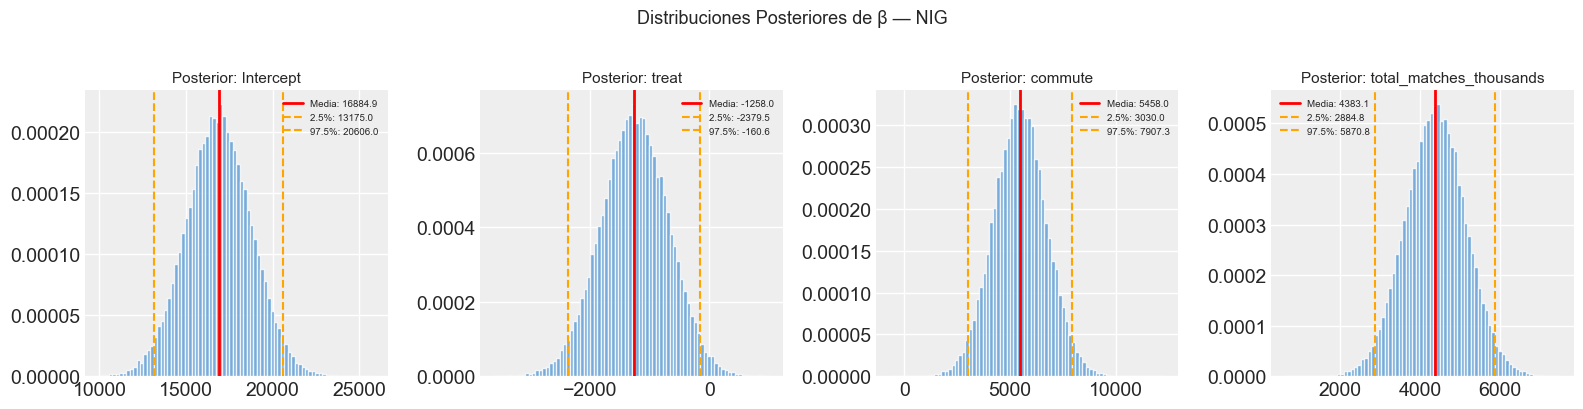

In [6]:
np.random.seed(42)
N = 50_000

# Paso 1: sigma^2 ~ Inv-Gamma(a_n, b_n)
sigma2_s = 1.0 / np.random.gamma(shape=a_n, scale=1.0/b_n, size=N)

# Paso 2: beta | sigma^2 ~ Normal(beta_n, sigma^2 * V_n)
L = np.linalg.cholesky(V_n)
z = np.random.randn(N, p)
beta_s = beta_n + np.sqrt(sigma2_s[:, None]) * (z @ L.T)

prob_neg = (beta_s[:, 1] < 0).mean()
print(f'P(beta_treat < 0 | y) = {prob_neg:.4f} ({prob_neg*100:.1f}%)')

fig, axes = plt.subplots(1, p, figsize=(16, 4))
for i, (ax, name) in enumerate(zip(axes, variables)):
    s = beta_s[:, i]
    lo, hi = np.percentile(s, [2.5, 97.5])
    ax.hist(s, bins=80, density=True, color='#5b9bd5', alpha=0.8, ec='white')
    ax.axvline(s.mean(), color='red', lw=2, label=f'Media: {s.mean():.1f}')
    ax.axvline(lo, color='orange', lw=1.5, ls='--', label=f'2.5%: {lo:.1f}')
    ax.axvline(hi, color='orange', lw=1.5, ls='--', label=f'97.5%: {hi:.1f}')
    ax.set_title(f'Posterior: {name}', fontsize=11)
    ax.legend(fontsize=7)
plt.suptitle('Distribuciones Posteriores de β — NIG', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

### 1.5 Chequeo Residual

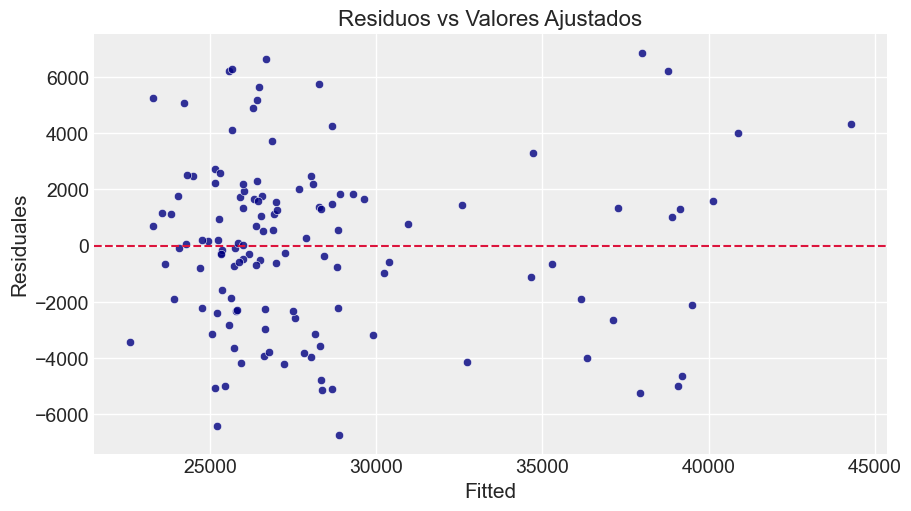

In [7]:
y_hat = X @ beta_n
res   = y - y_hat
plt.figure(figsize=(9, 5))
sns.scatterplot(x=y_hat, y=res, alpha=0.8, color='navy')
plt.axhline(0, color='crimson', ls='--')
plt.title('Residuos vs Valores Ajustados')
plt.xlabel('Fitted')
plt.ylabel('Residuales')
plt.show()

---
## Parte II: Regresión Logística Ordinal Bayesiana — Movistar Arena

Variable respuesta `Customer_Type` con orden natural: `Last-Minute` (0) < `In-Between` (1) < `Planner` (2).

### 2.1 Carga de Datos y EDA

In [8]:
df_arena = pd.read_excel('../Taller actual/movistar.xlsx')
order    = ['Last-Minute', 'In-Between', 'Planner']
num_cols = ['Age', 'Num_Tickets_Purchased', 'Ticket_Price',
            'Concession_Purchases', 'Days_Before_Concierto']
cat_cols = ['Fan_Mailing_List', 'Seat_Location']
print(f'Dataset: {df_arena.shape[0]} registros')
df_arena.head()

Dataset: 1000 registros


,customerID,customerName,Age,Fan_Mailing_List,Customer_Type,Concierto,Num_Tickets_Purchased,Seat_Location,Ticket_Price,Concession_Purchases,Days_Before_Concierto
0,84d6d15c19b7ef14,"el-Sadek, Lateefa",42,No,Last-Minute,324fd36f67eb,2,Upper,307.64,13.92,2
1,4d570962be6afdbd,"el-Shahan, Wadee'a",61,Yes,In-Between,0c4f632e4414,1,Upper,324.07,18.47,14
2,aaabe0dae9c355d2,"Legge, Megan",27,No,Last-Minute,2f73386a1b02,4,Upper,291.51,3.24,0
3,64f0b74afeb534da,"Burrows, Keenan",32,Yes,Last-Minute,0bdd7a9ec446,2,Upper,184.92,0.00,2
4,e2bef2d7b2a2de4d,"Waggoner, Lucas",34,No,Last-Minute,7040d6183039,1,Upper,198.40,0.00,1


--- Kruskal-Wallis ---
  Age                           : p=1.637e-127 *
  Num_Tickets_Purchased         : p=2.655e-97 *
  Ticket_Price                  : p=3.150e-07 *
  Concession_Purchases          : p=5.220e-59 *
  Days_Before_Concierto         : p=8.610e-192 *


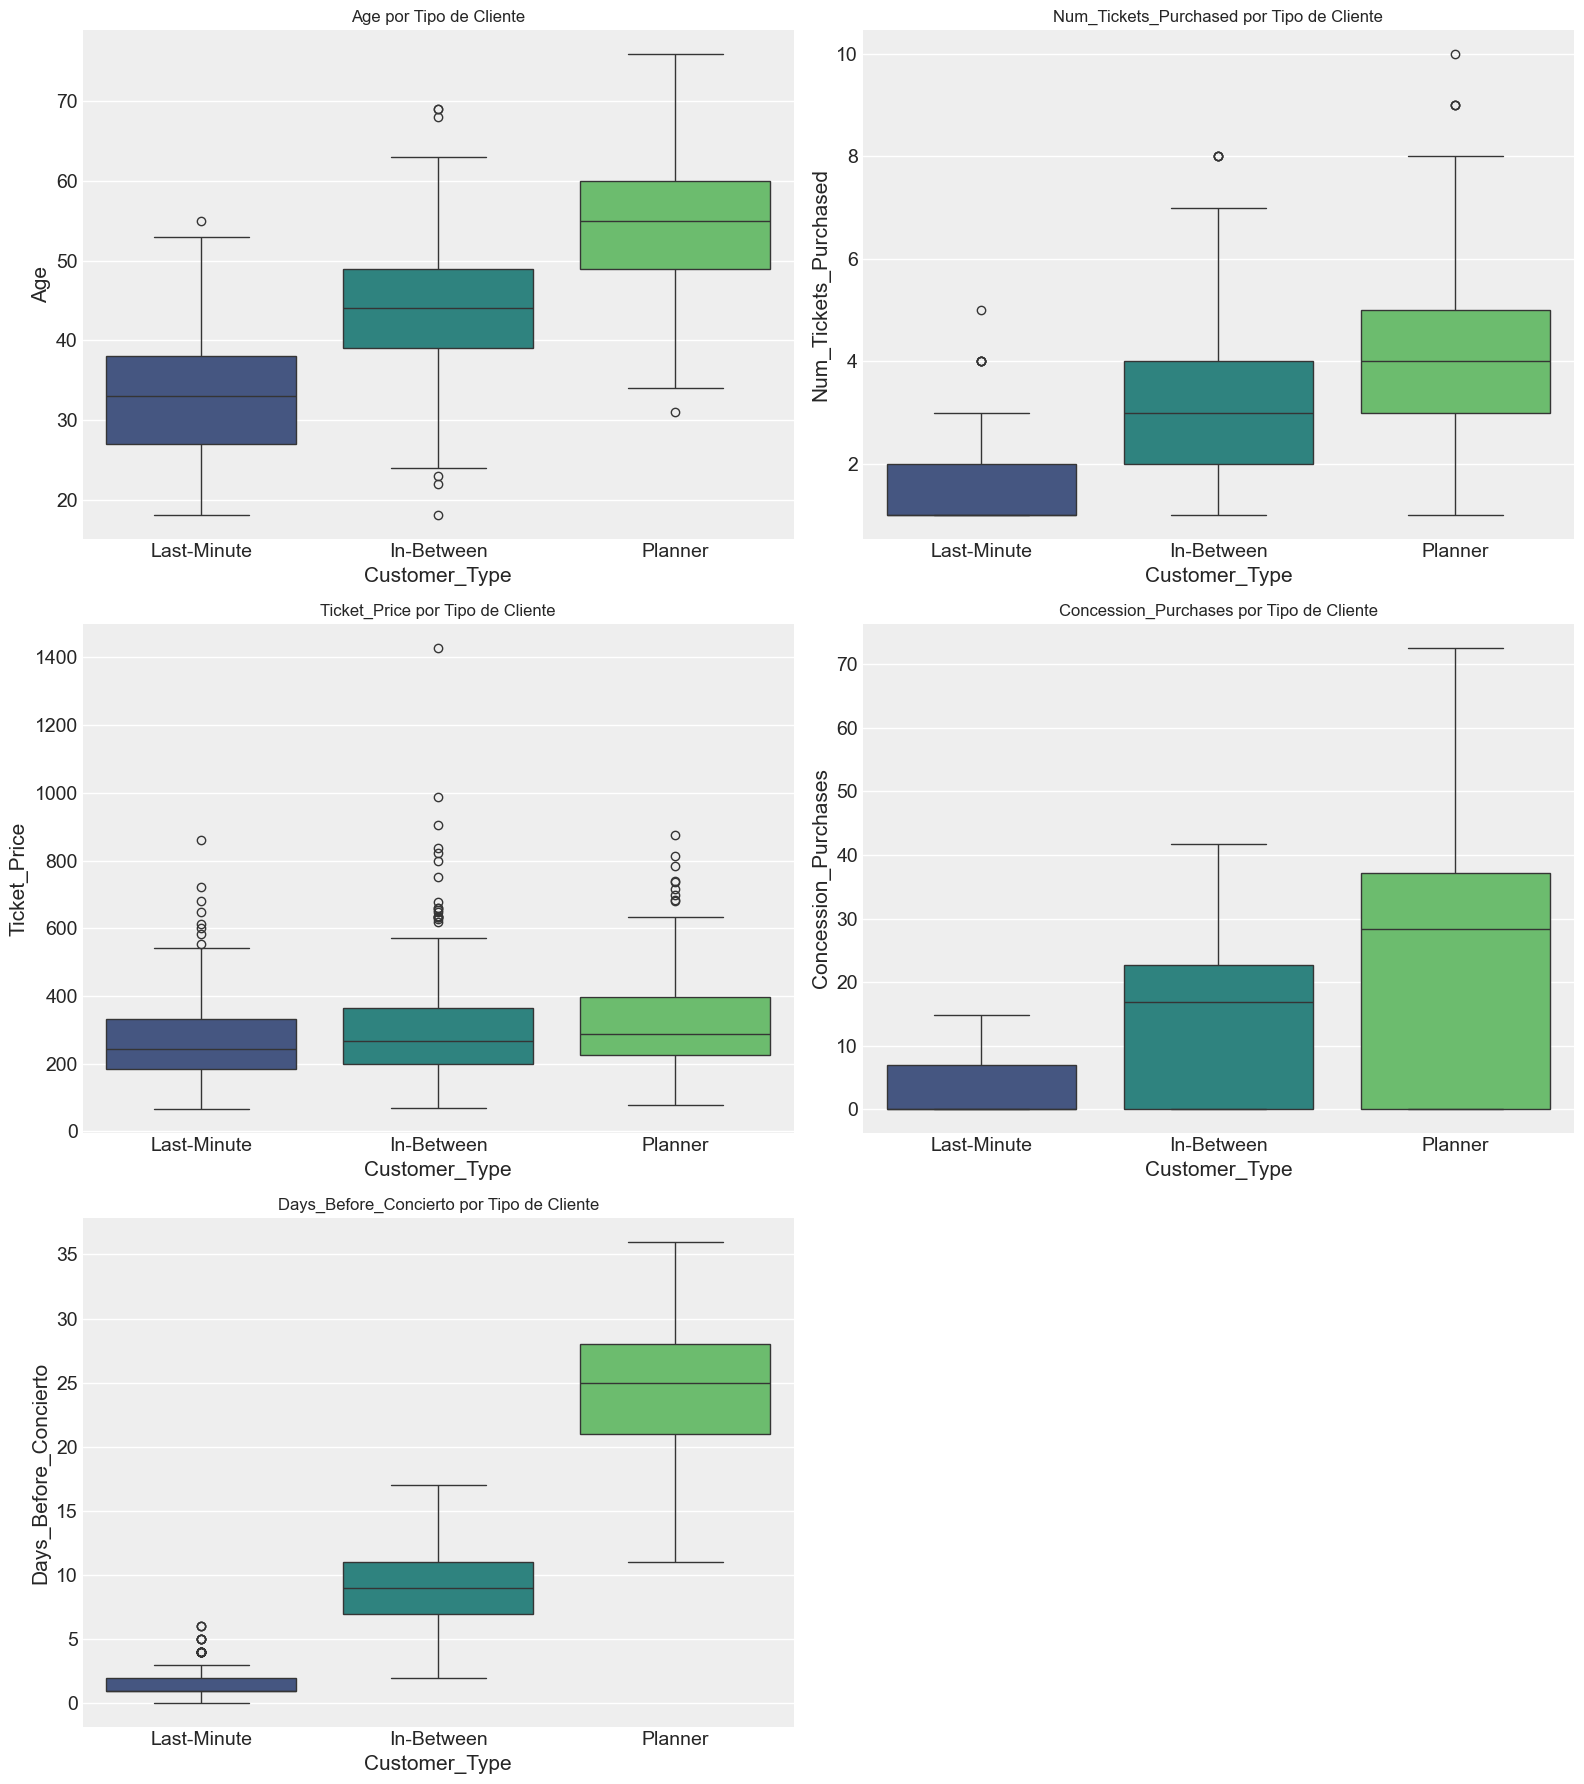


--- Chi-cuadrado ---
  Fan_Mailing_List              : p=2.255e-30 *


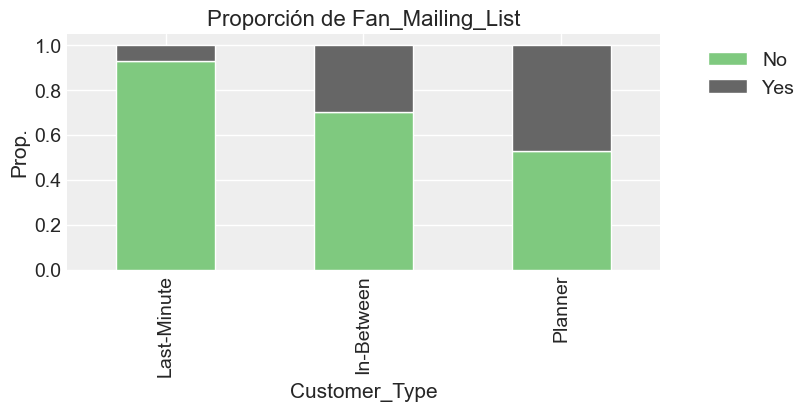

  Seat_Location                 : p=2.772e-47 *


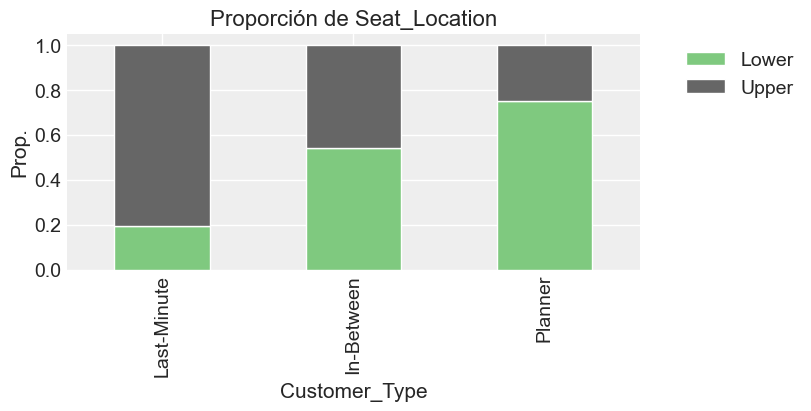

In [9]:
fig, axs = plt.subplots(3, 2, figsize=(16, 18))
axs = axs.flatten()
print('--- Kruskal-Wallis ---')
for i, col in enumerate(num_cols):
    df_arena[col] = pd.to_numeric(df_arena[col], errors='coerce')
    sns.boxplot(data=df_arena, x='Customer_Type', y=col, order=order,
                ax=axs[i], palette='viridis')
    axs[i].set_title(f'{col} por Tipo de Cliente', fontsize=12)
    groups = [df_arena[df_arena['Customer_Type']==ct][col].dropna() for ct in order]
    _, pv = stats.kruskal(*groups)
    sig = '*' if pv < 0.05 else ''
    print(f'  {col:30s}: p={pv:.3e} {sig}')
if len(num_cols) < len(axs):
    fig.delaxes(axs[-1])
plt.tight_layout()
plt.show()

print('\n--- Chi-cuadrado ---')
for col in cat_cols:
    ct = pd.crosstab(df_arena['Customer_Type'], df_arena[col])
    _, pv, *_ = stats.chi2_contingency(ct)
    sig = '*' if pv < 0.05 else ''
    print(f'  {col:30s}: p={pv:.3e} {sig}')
    pct = pd.crosstab(df_arena['Customer_Type'], df_arena[col], normalize='index')
    pct.loc[order].plot(kind='bar', stacked=True, figsize=(8, 4), colormap='Accent')
    plt.title(f'Proporción de {col}')
    plt.ylabel('Prop.')
    plt.legend(bbox_to_anchor=(1.05, 1))
    plt.show()

### 2.2 Modelo Ordinal Bayesiano

$$P(Y_i \leq k | \mathbf{X}_i) = \sigma(\theta_k - \mathbf{X}_i\boldsymbol{\beta})$$

**Priors:** $\beta \sim \mathcal{N}(0,1)$, $\sigma_{cp} \sim \text{Exp}(1)$, $\boldsymbol{\theta} \sim \mathcal{N}(0, \sigma_{cp})$ con transformación ordenada.

In [10]:
mapping = {'Last-Minute': 0, 'In-Between': 1, 'Planner': 2}
df_arena['Y_ordinal']      = pd.to_numeric(
    df_arena['Customer_Type'].map(mapping), downcast='integer')
df_arena['Fan_Mailing_Yes'] = (df_arena['Fan_Mailing_List'] == 'Yes').astype(int)
df_arena['Seat_Front']      = (df_arena['Seat_Location'] == 'Front').astype(int)
df_arena['Seat_Balcony']    = (df_arena['Seat_Location'] == 'Balcony').astype(int)

features = ['Age', 'Num_Tickets_Purchased', 'Ticket_Price',
            'Concession_Purchases', 'Fan_Mailing_Yes', 'Seat_Front', 'Seat_Balcony']
X_arena = df_arena[features].copy()
for f in ['Age', 'Num_Tickets_Purchased', 'Ticket_Price', 'Concession_Purchases']:
    X_arena[f] = (X_arena[f] - X_arena[f].mean()) / X_arena[f].std()

X_mat = X_arena.values
y_ord = df_arena['Y_ordinal'].values
k_classes, n_pred = 3, X_mat.shape[1]
print(f'Shape: {X_mat.shape}')
print(f'Y dist: {dict(pd.Series(y_ord).value_counts().sort_index())}')

Shape: (1000, 7)
Y dist: {0: np.int64(368), 1: np.int64(326), 2: np.int64(306)}


In [11]:
with pm.Model() as ordinal_model:
    beta      = pm.Normal('beta', mu=0, sigma=1, shape=n_pred)
    sigma_cp  = pm.Exponential('sigma_cp', lam=1)
    cutpoints = pm.Normal(
        'cutpoints', mu=0, sigma=sigma_cp,
        transform=pm.distributions.transforms.ordered,
        shape=k_classes - 1,
        initval=np.array([-1.0, 1.0])
    )
    eta   = pm.math.dot(X_mat, beta)
    y_obs = pm.OrderedLogistic('y_obs', eta=eta, cutpoints=cutpoints, observed=y_ord)
    trace = pm.sample(draws=10_000, tune=2_000, chains=4, target_accept=0.9, random_seed=42)

Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [beta, sigma_cp, cutpoints]


Output()

Sampling 4 chains for 2_000 tune and 10_000 draw iterations (8_000 + 40_000 draws total) took 28187 seconds.


### 2.3 Diagnóstico MCMC

$b_0$ (Age): Edad del cliente. Un valor positivo indica que a mayor edad, hay una mayor probabilidad de ser un cliente tipo "Planner" (que compra con anticipación).

$b_1$ (Num_Tickets_Purchased): Cantidad de boletos comprados en la transacción.

$b_2$ (Ticket_Price): Precio del boleto (normalizado).

$b_3$ (Concession_Purchases): Monto gastado en compras de comida o mercancía (concesiones).

$b_4$ (Fan_Mailing_Yes): Variable binaria que indica si el cliente está en la lista de correos de fans (1 si es "Yes", 0 si es "No").

$b_5$ (Seat_Front): Variable binaria que indica si el asiento está en la zona frontal ("Front").

$b_6$ (Seat_Balcony): Variable binaria que indica si el asiento esta en la zona de balcon

Nota importante sobre el modelo: En la regresión logística ordinal no se incluye un intercepto explícito como en la regresión lineal o logística binaria. En su lugar, el modelo incorpora múltiples puntos de corte (cutpoints), los cuales actúan como interceptos implícitos que delimitan las fronteras entre las categorías en la escala latente. Incluir simultáneamente un intercepto y los cutpoints generaría problemas de identificabilidad..

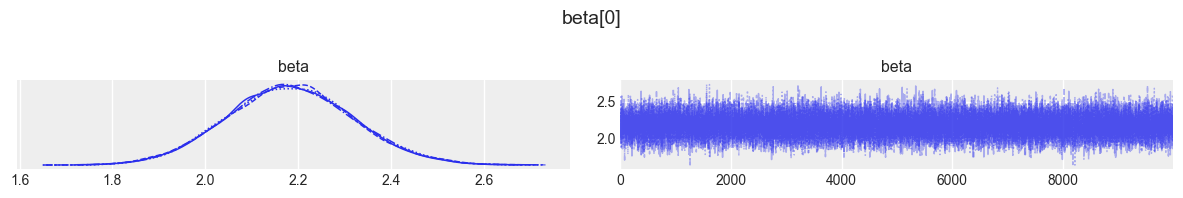

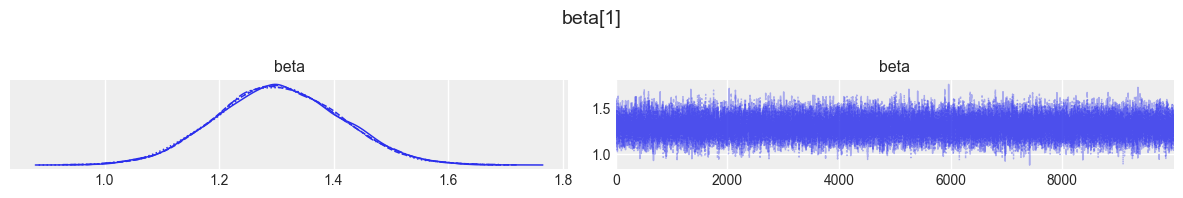

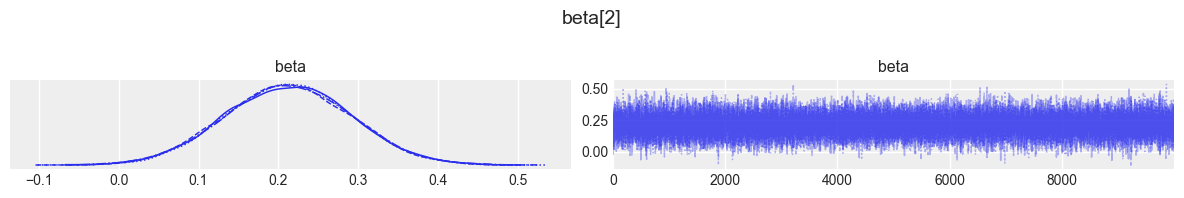

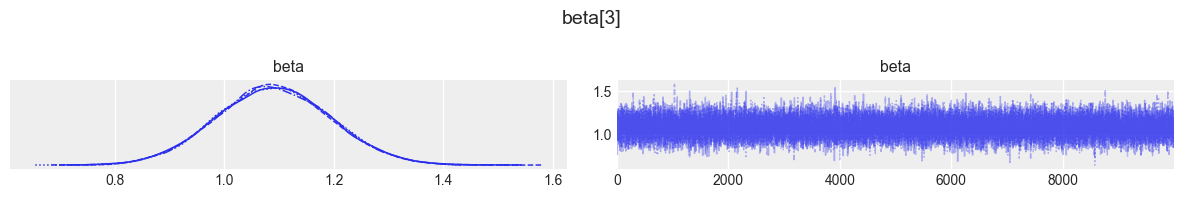

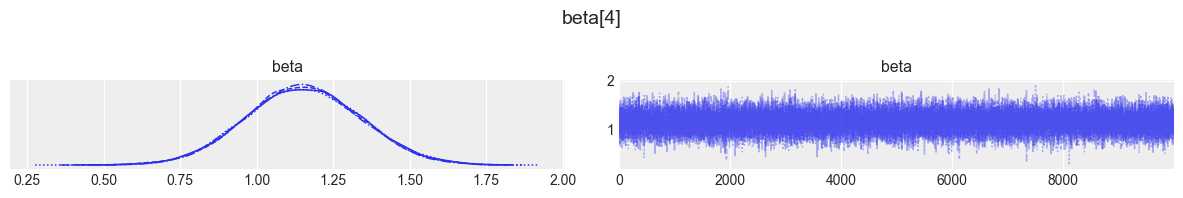

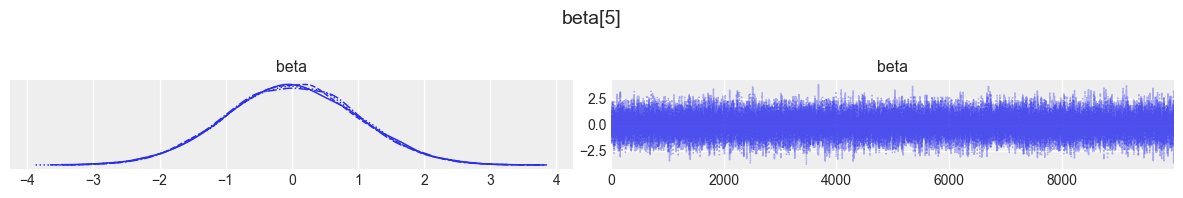

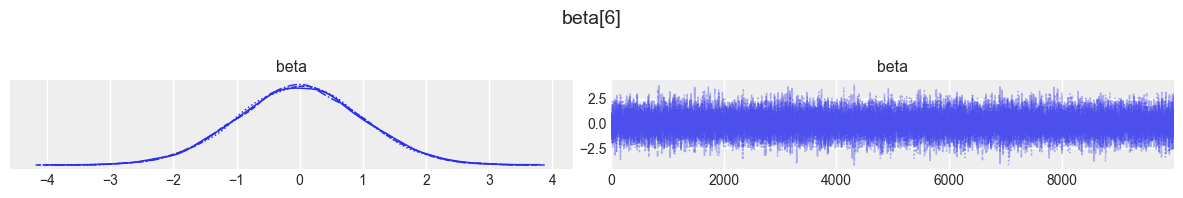

In [22]:
for i in range(len(beta_m)):
    az.plot_trace(
        trace,
        var_names=['beta'],
        coords={'beta_dim_0': [i]}
    )
    plt.suptitle(f'beta[{i}]', fontsize=14)
    plt.tight_layout()
    plt.show()

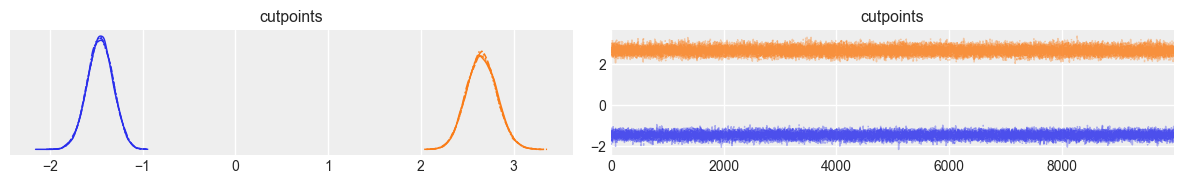

In [12]:
az.plot_trace(trace, var_names=['cutpoints'])
plt.tight_layout()
plt.show()

In [13]:
summary_diag = az.summary(trace, var_names=['beta', 'cutpoints', 'sigma_cp'])
print(summary_diag[['mean','sd','hdi_3%','hdi_97%','r_hat','ess_bulk']].round(3))

               mean     sd  hdi_3%  hdi_97%  r_hat  ess_bulk
beta[0]       2.184  0.137   1.924    2.439    1.0   28618.0
beta[1]       1.304  0.109   1.101    1.507    1.0   32591.0
beta[2]       0.212  0.079   0.061    0.357    1.0   46996.0
beta[3]       1.090  0.105   0.895    1.288    1.0   33824.0
beta[4]       1.153  0.188   0.799    1.503    1.0   45528.0
beta[5]      -0.003  0.998  -1.850    1.897    1.0   48423.0
beta[6]       0.000  0.999  -1.866    1.894    1.0   51757.0
cutpoints[0] -1.457  0.138  -1.720   -1.202    1.0   20607.0
cutpoints[1]  2.655  0.163   2.349    2.962    1.0   26544.0
sigma_cp      2.081  0.826   0.849    3.566    1.0   40224.0


### 2.4 Resultados

In [14]:
res_ord = az.summary(trace, var_names=['beta', 'cutpoints'])
res_ord.index = features + ['cutpoint_0', 'cutpoint_1']
res_ord[['mean','sd','hdi_3%','hdi_97%']].round(3)

,mean,sd,hdi_3%,hdi_97%
Age,2.184,0.137,1.924,2.439
Num_Tickets_Purchased,1.304,0.109,1.101,1.507
Ticket_Price,0.212,0.079,0.061,0.357
Concession_Purchases,1.090,0.105,0.895,1.288
Fan_Mailing_Yes,1.153,0.188,0.799,1.503
Seat_Front,-0.003,0.998,-1.850,1.897
Seat_Balcony,0.000,0.999,-1.866,1.894
cutpoint_0,-1.457,0.138,-1.720,-1.202
cutpoint_1,2.655,0.163,2.349,2.962


**Interpretación Estadística:**
- Los **puntos de corte** conservan el orden $\theta_1 < \theta_2$, particionando correctamente el espacio latente.
- **Edad** y **Compras en Concesión** impulsan valores positivos: mayor propensión a ser *Planner*.
- Los **94% HDI** cuantifican la incertidumbre Bayesiana de cada efecto.

### 2.5 Distribuciones Posteriores

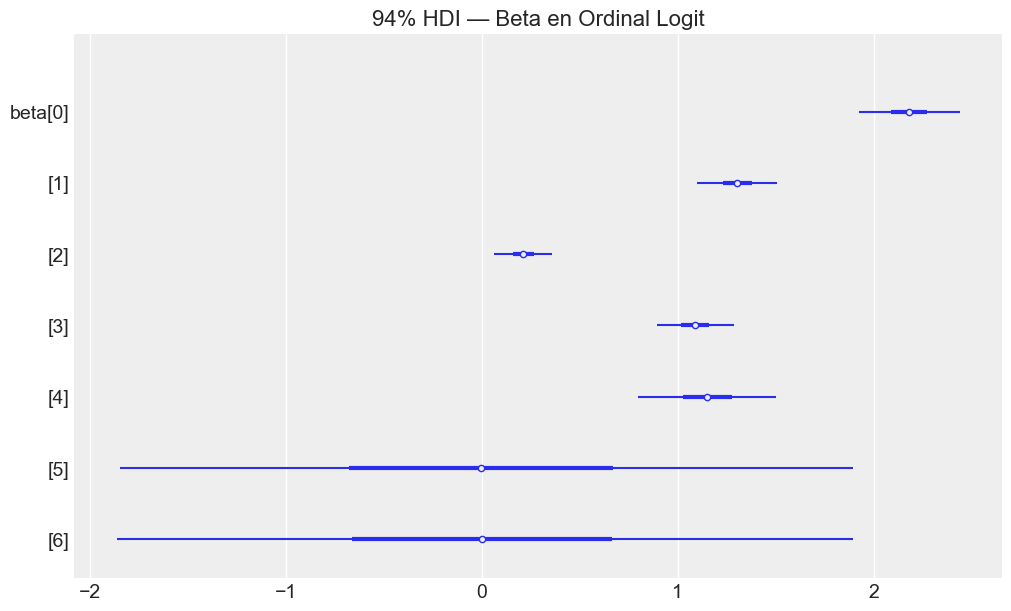

In [15]:
az.plot_forest(trace, var_names=['beta'], combined=True, figsize=(10, 6))
plt.title('94% HDI — Beta en Ordinal Logit')
plt.show()

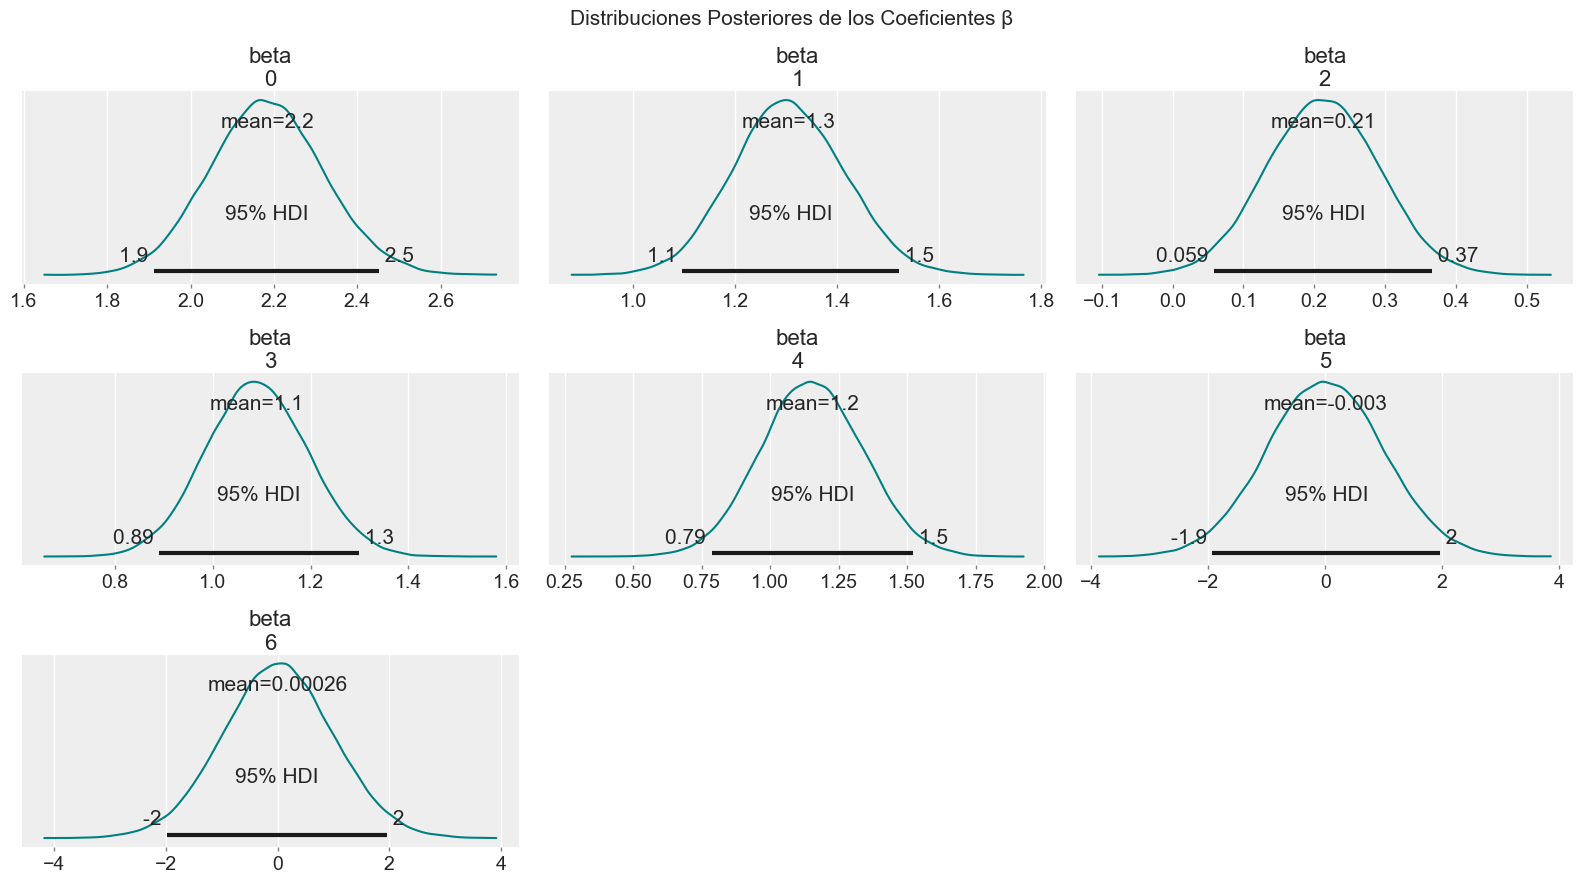

In [16]:
az.plot_posterior(trace, var_names=['beta'], hdi_prob=0.95, color='teal', figsize=(16, 9))
plt.suptitle('Distribuciones Posteriores de los Coeficientes β', fontsize=15)
plt.tight_layout()
plt.show()

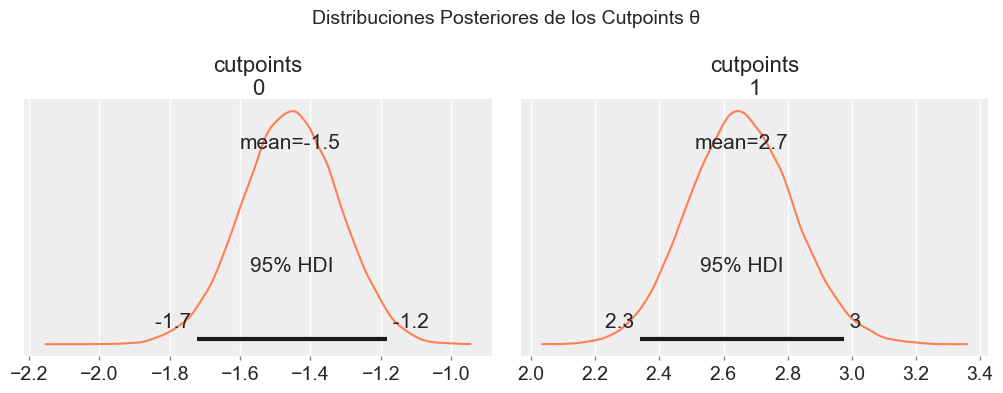

In [17]:
az.plot_posterior(trace, var_names=['cutpoints'], hdi_prob=0.95, color='coral', figsize=(10, 4))
plt.suptitle('Distribuciones Posteriores de los Cutpoints θ', fontsize=14)
plt.tight_layout()
plt.show()

### 2.6 Probabilidades Implicadas — Individuo 0

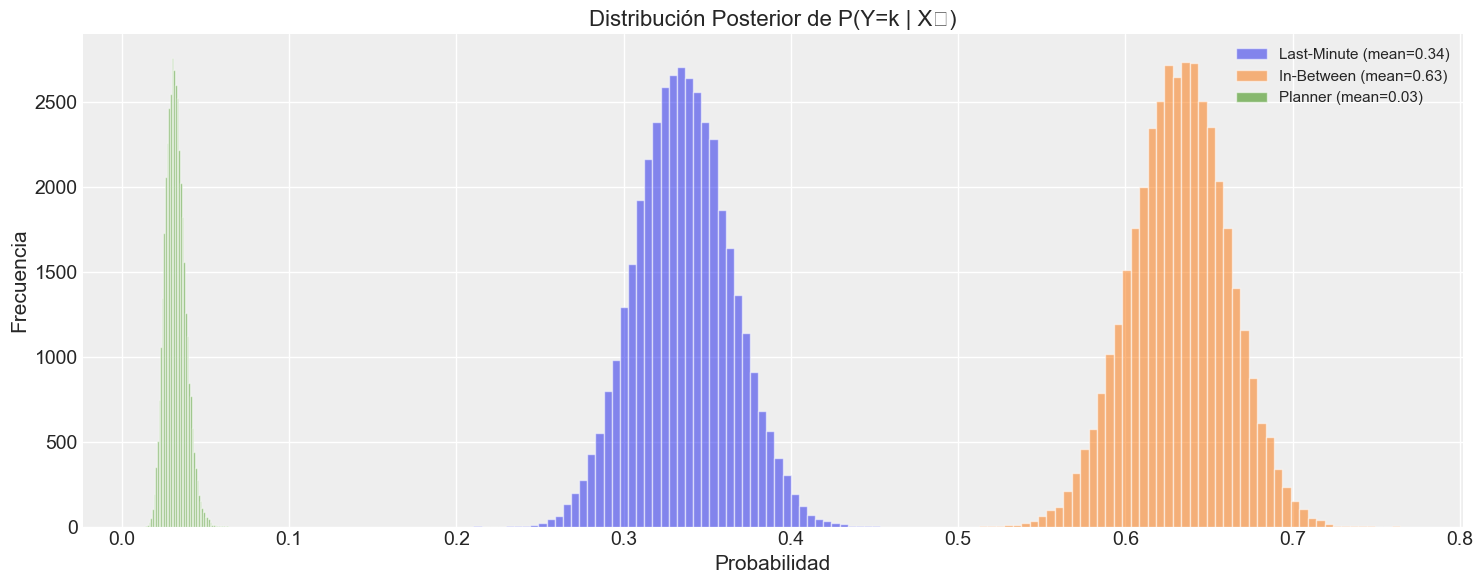

In [18]:
beta_s2 = trace.posterior['beta'].values.reshape(-1, n_pred)
cp_s    = trace.posterior['cutpoints'].values.reshape(-1, k_classes - 1)
eta0    = np.dot(beta_s2, X_mat[0])
pk0     = expit(cp_s[:, 0] - eta0)
pk1     = expit(cp_s[:, 1] - eta0)
probs   = np.array([pk0, pk1 - pk0, 1 - pk1])
labels_cat = ['Last-Minute', 'In-Between', 'Planner']

fig, ax = plt.subplots(figsize=(15, 6))
for i in range(3):
    ax.hist(probs[i], label=f'{labels_cat[i]} (mean={probs[i].mean():.2f})',
            ec='white', bins=50, alpha=0.55)
ax.set_xlabel('Probabilidad')
ax.set_ylabel('Frecuencia')
ax.set_title('Distribución Posterior de P(Y=k | X₀)', fontsize=16)
ax.legend(fontsize=11)
plt.tight_layout()
plt.show()

### 2.7 Espacio Latente

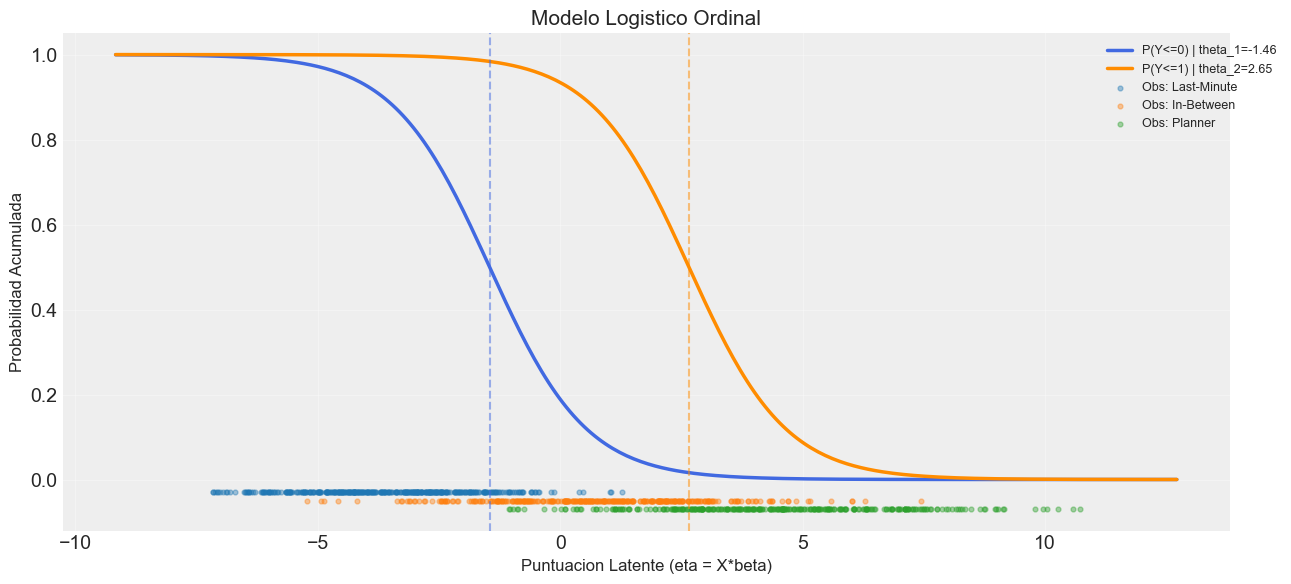

In [19]:
beta_m  = trace.posterior['beta'].mean(dim=('chain','draw')).values
theta_m = trace.posterior['cutpoints'].mean(dim=('chain','draw')).values
eta_obs = X_mat @ beta_m
eta_g   = np.linspace(eta_obs.min()-2, eta_obs.max()+2, 300)

fig, ax = plt.subplots(figsize=(13, 6))
ax.plot(eta_g, expit(theta_m[0]-eta_g), lw=2.5, color='royalblue',
        label=f'P(Y<=0) | theta_1={theta_m[0]:.2f}')
ax.plot(eta_g, expit(theta_m[1]-eta_g), lw=2.5, color='darkorange',
        label=f'P(Y<=1) | theta_2={theta_m[1]:.2f}')
ax.axvline(theta_m[0], color='royalblue', ls='--', alpha=0.5)
ax.axvline(theta_m[1], color='darkorange', ls='--', alpha=0.5)
for i, (cat, col) in enumerate(zip(labels_cat, ['#1f77b4','#ff7f0e','#2ca02c'])):
    idx = (y_ord == i)
    ax.scatter(eta_obs[idx], np.full(idx.sum(), -0.03-i*0.02),
               alpha=0.4, s=12, color=col, label=f'Obs: {cat}')
ax.set_xlabel('Puntuacion Latente (eta = X*beta)', fontsize=12)
ax.set_ylabel('Probabilidad Acumulada', fontsize=12)
ax.set_title('Modelo Logistico Ordinal', fontsize=15)
ax.legend(bbox_to_anchor=(1.05, 1), fontsize=9)
ax.set_ylim(-0.12, 1.05)
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
## Discusión Integrada

**Parte I:** La solución NIG confirma $\beta_{\text{treat}} \approx -1253$ (CrI 95%: [−2357, −159]). UBER Pool redujo el pago al conductor a corto plazo. Sin embargo, `total_matches_thousands` tiene un efecto masivamente positivo: la rentabilidad depende de la **densidad de emparejamientos**.

**Parte II:** Los **Planners** (compradores anticipados) tienen mayor edad y gasto en concesiones. Su decisión >14 días antes permite planificación logística agregada.

**Recomendación:** Una alianza Movistar Arena–Uber ofreciendo *Uber Pool Programado* a perfiles Planner resuelve simultáneamente la baja densidad (Parte I) y agrega valor al comprador premium (Parte II).